## Exercise 1

In [ ]:
# Useful Libraries and Customisations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings


from pandas.plotting import autocorrelation_plot

from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA

from sklearn import linear_model
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


#from pmdarima as pm
from scipy.stats import chi2
from scipy.stats import ttest_ind, f_oneway
from scipy.stats import ttest_1samp
from arch import arch_model


from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"
pd.options.display.max_columns = None 
pd.options.display.width=None

sns.set_theme(style="darkgrid")

warnings.filterwarnings("ignore")

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 16
plt.rcParams["figure.titlesize"] = 16

plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [58]:
# read exchage data from csv file.
fx_prices = pd.read_csv("datasets/exchange_rates_1.csv", index_col="Date", parse_dates=["Date"])
fx_prices.columns = ["USDINR", "GBPINR", "EURINR"]
fx_prices.round(3).head()


,USDINR,GBPINR,EURINR
Date,,,
2006-12-04,44.590,88.240,59.400
2006-12-05,45.097,89.271,60.174
2006-12-06,44.694,87.952,59.382
2006-12-07,44.657,87.940,59.435
2006-12-08,44.655,87.604,59.340


In [ ]:
# check for data sanity
fx_prices.info()
print("\n")
fx_prices.describe()

In [ ]:
# visualise the series 
fig, ax = plt.subplots(figsize=(12, 8))
_ = fx_prices.plot(ax=ax)
_= plt.ylabel("FX Rates")
_= plt.title("Fx rate: Indian Rupee  Vs USD, GBP and EUR", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

In [59]:
# Generate returns (Standardize on log returns)
fx_returns = fx_prices.apply(lambda x: np.log(x) - np.log(x).shift(1)).dropna()

# compute basic statistics for returns
stats = pd.concat({"obs": fx_returns.apply(lambda x: x.shape[0]),
                   "mean": fx_returns.mean(axis=0),
                   "std": fx_returns.std(axis=0),
                   "autocorrelation": fx_returns.apply(lambda s: s.autocorr(lag=1)),
                   "acf_bounds": fx_returns.apply(lambda s: f"=+/-{np.round(2/np.sqrt(s.shape[0]),4)}") # confidence bounds for autocorrelation at 95% confidence level

}, axis=1)
# stats results show none of the acf is statistically significant (compare against the bounds)

In [60]:
# Test the mean Zero hypothesis (Using scipy ttest)
pd.DataFrame({"T-test_p-value": fx_returns.apply(lambda x: ttest_1samp(x,0)[1])})

# Null hypothesis cannot be reject for mean zero for all three series

,T-test_p-value
USDINR,0.951264
GBPINR,0.417172
EURINR,0.842512


In [61]:
# Test for first order autocorrelation using Ljung-Box test
pd.DataFrame({"LJung-Box_p-value": fx_returns.apply(lambda x: acorr_ljungbox(x, lags=[1], return_df=True)["lb_pvalue"].values[0])})

# Null hypothesis of no autocorrelation cannot be rejected for all three series

,LJung-Box_p-value
USDINR,0.128094
GBPINR,0.625325
EURINR,0.086598


## Question 2

In [ ]:
# plot histograms of return values
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
_ = fx_returns.hist(bins=30, ax=ax.reshape(4)[0:3])
_ = ax[1,1].set_visible(False)
plt.show()

# Plot is higher and skewed than normal distribution, which is a common feature of financial returns.

In [11]:
# Normal test using Jarque and Bera Goodness fit
pd.DataFrame({"jarque_bera_p-value": fx_returns.apply(lambda x: jarque_bera(x)[1])})

# Null hypothesis of normal distribution is rejected for all three series (p-values are essentially zero)

,jarque_bera_p-value
USDINR,9.657613e-88
GBPINR,8.096584e-73
EURINR,9.137560e-154


## Question 3

In [12]:
# Resample data to create weekly dataset

fx_weekly_prices = fx_prices.resample("W").first()
fx_weekly_returns = fx_weekly_prices.apply(lambda x: np.log(x) - np.log(x).shift(1)).dropna()

# Repeate basic statistics
weekly_stats = pd.concat({"obs": fx_weekly_returns.apply(lambda x: x.shape[0]),
                          "mean": fx_weekly_returns.mean(axis=0),
                          "std": fx_weekly_returns.std(axis=0),
                          "autocorrelation": fx_weekly_returns.apply(lambda s: s.autocorr(lag=1)),
                          "ac_bounds": fx_weekly_returns.apply(lambda s: f"=+/-{np.round(2/np.sqrt(s.shape[0]),4)}")

}, axis=1)

weekly_stats

,obs,mean,std,autocorrelation,ac_bounds
USDINR,204,-0.000007,0.011966,0.115449,=+/-0.14
GBPINR,204,-0.001022,0.016916,-0.123775,=+/-0.14
EURINR,204,0.000215,0.014977,-0.059014,=+/-0.14


In [13]:
# Repeat normality tests
pd.DataFrame({"T-test_p-value": fx_weekly_returns.apply(lambda x: ttest_1samp(x,0)[1])})
pd.DataFrame({"LJung-Box_p-value": fx_weekly_returns.apply(lambda x: acorr_ljungbox(x, lags=[1], return_df=True)["lb_pvalue"].values[0])})
pd.DataFrame({"jarque_bera_p-value": fx_weekly_returns.apply(lambda x: jarque_bera(x)[1])})
"""
    Summary: Hypothesis tests for mean zero, autocorrelation and normality for weekly returns show similar results as daily returns.
"""

,T-test_p-value
USDINR,0.993264
GBPINR,0.389099
EURINR,0.837707


,LJung-Box_p-value
USDINR,0.096858
GBPINR,0.076606
EURINR,0.396173


,jarque_bera_p-value
USDINR,2.347311e-07
GBPINR,2.355458e-77
EURINR,4.073317e-03


'\n    Summary: Hypothesis tests for mean zero, autocorrelation and normality for weekly returns show similar results as daily returns.\n'

## Exercise 2

### Question 1

In [ ]:
""" We will construct ARMA model for the return values. """

# Model Identification via ACF and PACF plots
# 1. USDINR
fig, (ax1,ax2,ax3) = plt.subplots(3,1, figsize=(12,15))
_= fx_returns.USDINR.plot(ax=ax1)
_= ax1.set_title("Return series for USDINR", fontsize=16)
_= plot_acf(fx_returns.USDINR, ax=ax2, zero=True, alpha=0.05, lags=10)
_= ax2.set_title("ACF for USDINR", fontsize=16)
_= plot_pacf(fx_returns.USDINR, ax=ax3, zero=True, alpha=0.005, lags=10)
_= ax3.set_title("PACF for USDINR", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

""" The ACF and PACF plots show no significant autocorrelation at any lag. """


In [ ]:
# 2. GBPINR
fig, (ax1,ax2,ax3) = plt.subplots(3,1, figsize=(12,15))
_= fx_returns.GBPINR.plot(ax=ax1)
_= ax1.set_title("Return series for GBPINR", fontsize=16)
_= plot_acf(fx_returns.GBPINR, ax=ax2, zero=True, alpha=0.05, lags=10)
_= ax2.set_title("ACF for GBPINR", fontsize=16)
_= plot_pacf(fx_returns.GBPINR, ax=ax3, zero=True, alpha=0.005, lags=10)
_= ax3.set_title("PACF for GBPINR", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

""" The ACF and PACF plots show  significant autocorrelation at lag 3. 
    Next is to contruct ARMA for GBPINR. Starting with a simple MA(3)"""


In [16]:
 # Testing MA(3) for GBPINR
results = ARIMA(fx_returns.GBPINR, order=(0,0,3)).fit()
results.summary()

""" Lag 3 coefficient is significant. Next lets look at the residuals to check if there is any significant autocorrelation left. """

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 GBPINR   No. Observations:                 1001
Model:                 ARIMA(0, 0, 3)   Log Likelihood                3406.578
Date:                Sun, 17 May 2026   AIC                          -6803.156
Time:                        13:57:54   BIC                          -6778.612
Sample:                             0   HQIC                         -6793.828
                               - 1001                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.000     -0.951      0.342      -0.001       0.000
ma.L1         -0.0179      0.023     -0.779      0.436      -0.063       0.027
ma.L2         -0.0431      0.024     -1.761      0.078      -0.091       0.005
ma.L3         -0.0955      0.023     -4.174      0.000      -0.140      -0.051
sigma2      6.475e-05   1.97e-06     32.937      0.000    6.09e-05    6.86e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):               356.14
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):               1.52   Skew:                            -0.51
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

' Lag 3 coefficient is significant. Next lets look at the residuals to check if there is any significant autocorrelation left. '

In [ ]:
# Plot residuals
fig, ax = plt.subplots(figsize=(12, 8))
_= plt.plot(results.resid)
_= plt.ylabel("Residuals")
_= plt.xlabel("Date")
_= ax.set_title("Residuals from MA(3) model for GBPINR", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

""" Some volatility structure but the residuals are practically white noise."""

In [ ]:
# 3. EURINR
fig, (ax1,ax2,ax3) = plt.subplots(3,1, figsize=(12,15))
_= fx_returns.EURINR.plot(ax=ax1)
_= ax1.set_title("Return series for EURINR", fontsize=16)
_= plot_acf(fx_returns.EURINR, ax=ax2, zero=True, alpha=0.05, lags=10)
_= ax2.set_title("ACF for EURINR", fontsize=16)
_= plot_pacf(fx_returns.EURINR, ax=ax3, zero=True, alpha=0.005, lags=10)
_= ax3.set_title("PACF for EURINR", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

""" The ACF and PACF plots show  significant autocorrelation at lag 8. 
   We will not pursue ARMA modelling for USDINR as the autocorrelation is very weak and there is no significant autocorrelation at lower lags. """

### Question 2

In [19]:
""" We will fit GARCH models on the squared returns (as a proxy for volatility) """

# 1. USDINR
am = arch_model(fx_returns.USDINR, mean="Constant", p=1, q=1)
res_usd = am.fit()
res_usd.summary()

' We will fit GARCH models on the squared returns (as a proxy for volatility) '

Iteration:      1,   Func. Count:      6,   Neg. LLF: 31978206145.612164
Iteration:      2,   Func. Count:     19,   Neg. LLF: 689245640286012.5
Iteration:      3,   Func. Count:     34,   Neg. LLF: 1650983831.5705256
Iteration:      4,   Func. Count:     46,   Neg. LLF: -3854.2668378651356
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3854.2668342407956
            Iterations: 8
            Function evaluations: 46
            Gradient evaluations: 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 USDINR   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3854.27
Distribution:                  Normal   AIC:                          -7700.53
Method:            Maximum Likelihood   BIC:                          -7680.90
                                        No. Observations:                 1001
Date:                Sun, May 17 2026   Df Residuals:                     1000
Time:                        13:57:56   Df Model:                            1
                                   Mean Model                                  
===============================================================================
                  coef    std err          t      P>|t|        95.0% Conf. Int.
-------------------------------------------------------------------------------
mu         -1.0531e-04  2.354e-06    -44.746      0.000 [-1.099e-04,-1.007e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      6.3494e-07  4.585e-11  1.385e+04      0.000 [6.349e-07,6.350e-07]
alpha[1]       0.1000  2.505e-02      3.992  6.543e-05   [5.091e-02,  0.149]
beta[1]        0.8800  2.334e-02     37.710      0.000     [  0.834,  0.926]
============================================================================

Covariance estimator: robust
"""

In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,15))
_ = (np.sqrt(250)*res_usd.conditional_volatility).plot(ax=ax1)
_ = ax1.set_title("Conditional Volatility for USDINR", fontsize=16)
_ = ax1.set_ylabel("Annualised Volatility")
_ = plot_acf(res_usd.conditional_volatility, ax=ax2)
_ = ax2.set_xlabel("Lags")
_ = ax2.set_ylabel("ACF")
_ = ax2.set_title("ACF of Conditional Volatility for USDINR", fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

In [21]:
# 2. GBPINR
am = arch_model(fx_returns.GBPINR, mean="Constant", p=1, q=1)
res_gbp = am.fit()
res_gbp.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 3626591731.9008436
Iteration:      2,   Func. Count:     19,   Neg. LLF: 96911859200075.5
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3531.301361194095
            Iterations: 2
            Function evaluations: 29
            Gradient evaluations: 2


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 GBPINR   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3531.30
Distribution:                  Normal   AIC:                          -7054.60
Method:            Maximum Likelihood   BIC:                          -7034.97
                                        No. Observations:                 1001
Date:                Sun, May 17 2026   Df Residuals:                     1000
Time:                        13:57:58   Df Model:                            1
                                  Mean Model                                  
==============================================================================
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -1.2120e-04  2.082e-04     -0.582      0.560 [-5.292e-04,2.869e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.3113e-06  1.492e-09    878.721      0.000 [1.308e-06,1.314e-06]
alpha[1]       0.1000  1.899e-02      5.267  1.389e-07   [6.279e-02,  0.137]
beta[1]        0.8800  1.573e-02     55.931      0.000     [  0.849,  0.911]
============================================================================

Covariance estimator: robust
"""

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,15))
_ = (np.sqrt(250)*res_gbp.conditional_volatility).plot(ax=ax1)
_ = ax1.set_title('Anualized Conditional Volatility for GBPINR')
_ = ax1.set_ylabel('Conditional Vol')
_ = plot_acf(res_gbp.conditional_volatility,ax=ax2)
_ = ax2.set_xlabel('Lags')
_ = ax2.set_ylabel('ACF')
_ = ax2.set_title('ACF of Conditional Volatility')
plt.tight_layout()
sns.despine()
plt.show()

In [23]:
# 3 EURINR
am = arch_model(fx_returns.EURINR,mean='constant',p=1,q=1)
res_eur = am.fit()
res_eur.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 26318223.049425047
Iteration:      2,   Func. Count:     18,   Neg. LLF: -3614.830293157642
Optimization terminated successfully    (Exit mode 0)
            Current function value: -3614.830299224544
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 2


<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                 EURINR   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3614.83
Distribution:                  Normal   AIC:                          -7221.66
Method:            Maximum Likelihood   BIC:                          -7202.03
                                        No. Observations:                 1001
Date:                Sun, May 17 2026   Df Residuals:                     1000
Time:                        13:57:59   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         5.0306e-05  8.845e-05      0.569      0.570 [-1.231e-04,2.237e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      1.0553e-06  5.863e-11  1.800e+04      0.000 [1.055e-06,1.055e-06]
alpha[1]       0.0500  9.974e-03      5.013  5.360e-07 [3.045e-02,6.955e-02]
beta[1]        0.9300  8.112e-03    114.644      0.000     [  0.914,  0.946]
============================================================================

Covariance estimator: robust
"""

In [ ]:
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,15))
_ = (np.sqrt(250)*res_eur.conditional_volatility).plot(ax=ax1)
_ = ax1.set_title('Anualized Conditional Volatility for EURINR')
_ = ax1.set_ylabel('Conditional Vol')
_ = plot_acf(res_eur.conditional_volatility,ax=ax2)
_ = ax2.set_xlabel('Lags')
_ = ax2.set_ylabel('ACF')
_ = ax2.set_title('ACF of Conditional Volatility')
plt.tight_layout()
sns.despine()
plt.show()

In [25]:
# Summary:
pd.concat((res_usd.params, res_gbp.params, res_eur.params), axis=1, keys=["USDINR", "GBPINR", "EURINR"]).T


,mu,omega,alpha[1],beta[1]
USDINR,-0.000105,6.349424e-07,0.10,0.88
GBPINR,-0.000121,1.311318e-06,0.10,0.88
EURINR,0.000050,1.055287e-06,0.05,0.93


### Question 3 

In [ ]:
# Normalised plot of returns
fig, ax = plt.subplots(figsize=(12, 8))
_ = (1+fx_returns).cumprod().plot(ax=ax)
_ = plt.title("Normalised Price Plot")
plt.tight_layout()
sns.despine()
plt.show()
""" GBPINR and EURINR display a good amount of co-variation with peroads of decoupling. Particularly, late 2007 and most of 2009"""

## Excercise 3

In [27]:
# Read and prepare exhange rate data from csv file
fx_rate2 = pd.read_csv("datasets/exchange_rates_2.csv", index_col="DATE", parse_dates=True)
fx_rate2 = fx_rate2.drop(columns=["Unnamed: 0", "days"])
fx_rate2.index.name = "Date"

# Inspect data sanity
fx_rate2.info()
print("\n")
fx_rate2.describe()

# Remove NaN values from DataFrame
fx_rate2 = fx_rate2.dropna()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3200 entries, 2000-01-03 to 2012-04-10
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ARS     2678 non-null   float64
 1   AUD     2678 non-null   float64
 2   BRL     2678 non-null   float64
 3   CAD     2678 non-null   float64
 4   CHF     2678 non-null   float64
 5   CNY     3197 non-null   float64
 6   CZK     2678 non-null   float64
 7   DKK     3199 non-null   float64
 8   EUR     3200 non-null   float64
 9   GBP     2678 non-null   float64
 10  HKD     2678 non-null   float64
 11  HUF     2678 non-null   float64
 12  JPY     3197 non-null   float64
 13  KRW     2678 non-null   float64
 14  MXN     2678 non-null   float64
 15  NOK     2678 non-null   float64
 16  NZD     2678 non-null   float64
 17  PLN     2475 non-null   float64
 18  RUB     2100 non-null   float64
 19  SAR     2475 non-null   float64
 20  SEK     2678 non-null   float64
 21  SGD     2678 non-nu

,ARS,AUD,BRL,CAD,CHF,CNY,CZK,DKK,EUR,GBP,HKD,HUF,JPY,KRW,MXN,NOK,NZD,PLN,RUB,SAR,SEK,SGD,TRY,ZAR
count,2678.000000,2678.000000,2678.000000,2678.000000,2678.000000,3197.000000,2678.000000,3199.000000,3200.000000,2678.000000,2678.000000,2678.000000,3197.000000,2678.000000,2678.000000,2678.000000,2678.000000,2475.000000,2100.000000,2475.000000,2678.000000,2678.000000,2646.000000,2678.000000
mean,3.333810,0.795674,2.261462,1.186879,1.186892,7.649800,22.538717,6.292080,1.218440,1.716422,7.781118,206.693446,106.656639,1114.087919,11.459715,6.392963,0.670586,3.193495,28.419150,3.750087,7.450163,1.539762,1.465678,7.599623
std,0.510306,0.145110,0.554071,0.182861,0.185583,0.715184,4.942941,1.133297,0.197143,0.178055,0.020498,25.472072,14.364718,127.337191,1.200064,0.787570,0.100163,0.522529,2.519499,0.002943,0.984567,0.174524,0.157970,1.310547
min,1.000000,0.506050,1.538000,0.916050,0.727600,6.284000,14.505000,4.669550,0.828600,1.366850,7.712400,144.255000,75.760000,900.700000,8.991000,4.957200,0.414600,2.028500,23.102500,3.705500,5.847800,1.200700,1.150250,5.665500
25%,2.970000,0.707725,1.773425,1.028437,1.053875,6.832600,18.564750,5.479500,1.065900,1.574663,7.761850,189.338750,95.680000,1009.025000,10.745000,5.825425,0.614300,2.855050,26.723125,3.750200,6.794825,1.396962,1.346062,6.750750
50%,3.132500,0.773925,2.151400,1.151475,1.203325,8.048100,21.481000,5.880800,1.267400,1.666575,7.782550,205.330000,109.070000,1131.900000,11.076600,6.318200,0.690600,3.125350,28.515000,3.750300,7.266475,1.536950,1.462320,7.274650
75%,3.810000,0.904238,2.709575,1.303000,1.285275,8.276900,25.742125,6.966950,1.359575,1.866713,7.799250,220.716250,117.945000,1190.400000,12.427950,6.853150,0.742112,3.516375,30.297750,3.750400,7.837925,1.696675,1.562235,7.931437
max,4.387500,1.103000,3.999000,1.615600,1.718200,8.280000,37.041000,8.994800,1.598450,2.108350,7.829350,283.870000,134.800000,1570.300000,15.482500,9.113200,0.874850,4.290000,36.355000,3.770000,10.732700,1.853550,1.917000,12.550000


In [ ]:
# Test for normality via Q-Q plot and histogram
currencies = fx_rate2.columns
fx_returns = fx_rate2.apply(lambda x: np.log(x).diff()).dropna()

for cur in currencies:
    fxr = fx_returns.loc[:, cur]
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,8))

    _ = fig.suptitle(f"Histogram and QQ plot for {cur}", fontsize=16)
    _ = fxr.plot.hist(ax=ax1, bins=20, density=True)
    _ = ax1.set_xlabel("Log Returns")
    qqplot(fxr, line="45", ax=ax2, fit=True)
    fig.subplots_adjust(top=0.91)
    sns.despine()
    plt.tight_layout()
    fig.show()  

""" All three series show significant deviation from normal distribution, with fat tails and skewness. """ 

## Question 2

In [ ]:
def is_lag_significant(acf, c_m, c_u):
    return True if acf > c_u or acf < c_m else False

def color_false_red(val):
    color = "red" if val == True else "black"
    return "color: %s" % color

acf_info = []

for cur in currencies:

    fxr = fx_returns.loc[:, cur]
    acf_vals, conf_int = acf(fxr, nlags=10, alpha=0.05)
    df = pd.DataFrame([(fxr.name, i, is_lag_significant(acf_vals[i], conf_int[i][0] - acf_vals[i], conf_int[i][1] - acf_vals[i])) for i in range(1, 11)],
                       columns=["Currency", "Lag", "significant"])
    acf_info.append(df)

acf_info = pd.concat(acf_info).set_index(["Lag", "Currency"]).unstack()
acf_info.style.applymap(color_false_red)
"""Note: For the statsmodel acf function which also returns the confidence interval, we notice that the confidence intervals are centered around the acf value not around 0
   We subtract the acf value from to confidence interval to obtain 0 centered intervals"""



In [30]:
""" We will leverage PMDARIMA library to identify the best ARMA model for the return series. (We look for non-trivial ARMA(0,0) models) """

arma_best = []
try:

    for cur in currencies:
        fxr = fx_returns.loc[:, cur]
        model = pm.auto_arima(fxr, start_p=1, start_q=1, max_q=3, max_p=3, error_action="ignore", suppress_warnings=True, tarcee=False)
        arma = {"Currency": cur,
                "AR": model.order[0],
                "MA": model.order[2],
                "AIC": model.aic(),
                "BIC": model.bic()}
        arma_best.append(arma)
        arma_best = pd.DataFrame(arma_best).set_index("Currency")
        arma_best[(arma_best.AR + arma_best.MA) > 0]
except Exception as e:
    print("Error in PMDARIMA auto_arima: ", e)

""" pmdarima dependency is not working in the current environment. We will not be able to run auto_arima to identify the best ARMA model for the return series.
    However, we will see that a few currencies are represented by a meaningful ARMA Model  """

' We will leverage PMDARIMA library to identify the best ARMA model for the return series. (We look for non-trivial ARMA(0,0) models) '

Error in PMDARIMA auto_arima:  name 'pm' is not defined


' pmdarima dependency is not working in the current environment. We will not be able to run auto_arima to identify the best ARMA model for the return series.\n    However, we will see that a few currencies are represented by a meaningful ARMA Model  '

### Question 3

Testing for Arch effect in the return series using the __Lagrange Multiplier Test__

In [31]:
arch_effects = []

for cur in currencies:
    fxr2 =fx_returns.loc[:, cur]**2 # squared returns
    arch_lags = pd.concat([fxr2.shift(i) for i in range(1, 6)], axis=1).dropna()
    fxr2 = fxr2.loc[arch_lags.index]
    regr = linear_model.LinearRegression()
    _= regr.fit(arch_lags, fxr2)
    pred = regr.predict(arch_lags,)
    r2 = r2_score(fxr2, pred)
    p_value = chi2.sf(r2*arch_lags.shape[0],5)

    arch_effects.append({"Currency": fxr2.name, "r2": r2, "p_value": p_value})

arch_effects = pd.DataFrame(arch_effects).set_index("Currency")
arch_effects

""" For most currency pairs, there is significant ARCH effect as the p-values are very small. This means that the volatility of returns is not constant and can be modelled using GARCH models. """

,r2,p_value
Currency,,
ARS,0.072965,4.071098e-31
AUD,0.225860,9.625819e-100
BRL,0.201316,1.103503e-88
CAD,0.012172,1.152536e-04
CHF,0.005173,5.537595e-02
CNY,0.001008,8.344548e-01
CZK,0.000994,8.383345e-01
DKK,0.003573,1.883530e-01
EUR,0.004085,1.291906e-01


' For most currency pairs, there is significant ARCH effect as the p-values are very small. This means that the volatility of returns is not constant and can be modelled using GARCH models. '

In [32]:
def collect_results_garch(cur, m_id, model):
    out = {}
    out["Currency"] = cur
    out["ID"] = m_id
    out["Converged"] = model.convergence_flag ==0
    out["AIC"] = model.aic
    params = model.params
    t_values = model.tvalues
    out["Omega"] = f"{params['omega']:.4f} (t-value: {t_values['omega']:.2f})"
    out["Alpha_1"] = f"{params['alpha[1]']:.4f} (t-value: {t_values['alpha[1]']:.2f})" 
    out["Beta_1"] = f"{params['beta[1]']:.4f} (t-value: {t_values['beta[1]']:.2f})"
    return out

garch_models = []

for cur in currencies:
    fxr = fx_returns.loc[:,cur]
    model_N= arch_model(fxr,mean='Constant',vol='GARCH',p=1,q=1,dist='normal',rescale=True).fit(disp='off')
    garch_models.append(collect_results_garch(cur,'GARCH11_N',model_N))
    model_T = arch_model(fxr,mean='Constant',vol='GARCH',p=1,q=1,dist='studentst',rescale=True).fit(disp='off')
    garch_models.append(collect_results_garch(cur,'GARCH11_T',model_T))

garch_models = pd.DataFrame(garch_models).set_index(["Currency", "ID"])
garch_models

/var/folders/52/v4698xz56kzgcv6b6kmnnpm80000gn/T/ipykernel_1350/412108779.py:18: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  model_N= arch_model(fxr,mean='Constant',vol='GARCH',p=1,q=1,dist='normal',rescale=True).fit(disp='off')
/var/folders/52/v4698xz56kzgcv6b6kmnnpm80000gn/T/ipykernel_1350/412108779.py:20: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  model_T = arch_model(fxr,mean='Constant',vol='GARCH',p=1,q=1,dist='studentst',rescale=True).fit(disp='off')


Converged          AIC                    Omega  \
Currency ID                                                           
ARS      GARCH11_N       True  8065.443844   0.0373 (t-value: 2.34)   
         GARCH11_T       True  7635.601261   0.0429 (t-value: 1.68)   
AUD      GARCH11_N       True  4963.599178   0.0076 (t-value: 2.37)   
         GARCH11_T       True  4881.107046   0.0070 (t-value: 2.39)   
BRL      GARCH11_N       True  5196.779270   0.0466 (t-value: 1.37)   
         GARCH11_T       True  5009.415530   0.0172 (t-value: 2.17)   
CAD      GARCH11_N       True  4227.442348   0.0038 (t-value: 2.06)   
         GARCH11_T       True  4066.165226   0.0052 (t-value: 2.94)   
CHF      GARCH11_N       True  4585.803841   0.0035 (t-value: 0.91)   
         GARCH11_T       True  4337.508777   0.0081 (t-value: 2.76)   
CNY      GARCH11_N       True  5729.115693   0.1810 (t-value: 0.76)   
         GARCH11_T       True  4544.332666  0.6886 (t-value: 19.50)   
CZK      GARCH11_N       True  5291.276456   0.0052 (t-value: 0.74)   
         GARCH11_T       True  4885.025399   0.0054 (t-value: 2.09)   
DKK      GARCH11_N       True  4138.367650   0.0016 (t-value: 0.88)   
         GARCH11_T       True  3947.138009   0.0031 (t-value: 2.16)   
EUR      GARCH11_N       True  4132.352771   0.0015 (t-value: 0.90)   
         GARCH11_T       True  3946.349552   0.0030 (t-value: 2.14)   
GBP      GARCH11_N       True  3834.125804   0.0025 (t-value: 1.89)   
         GARCH11_T       True  3797.721565   0.0031 (t-value: 2.26)   
HKD      GARCH11_N       True  1361.202228   0.0171 (t-value: 1.47)   
         GARCH11_T       True  -666.581497   0.0000 (t-value: 1.99)   
HUF      GARCH11_N       True  5948.114405   0.0096 (t-value: 2.50)   
         GARCH11_T       True  5775.151373   0.0074 (t-value: 2.05)   
JPY      GARCH11_N       True  4140.626275   0.0098 (t-value: 1.44)   
         GARCH11_T       True  3936.062441   0.0059 (t-value: 1.42)   
KRW      GARCH11_N       True  3988.580255   0.0127 (t-value: 1.16)   
         GARCH11_T       True  3249.741773   0.0088 (t-value: 1.85)   
MXN      GARCH11_N       True  3558.330249   0.0035 (t-value: 2.09)   
         GARCH11_T       True  3454.563627   0.0035 (t-value: 2.13)   
NOK      GARCH11_N       True  5248.661247   0.0048 (t-value: 1.21)   
         GARCH11_T       True  5027.882741   0.0104 (t-value: 2.86)   
NZD      GARCH11_N       True  5439.626111   0.0107 (t-value: 2.38)   
         GARCH11_T       True  5317.832688   0.0135 (t-value: 2.53)   
PLN      GARCH11_N       True  6465.509091   0.0723 (t-value: 0.68)   
         GARCH11_T       True  5522.295831   0.0098 (t-value: 2.26)   
RUB      GARCH11_N       True  2198.034021   0.0008 (t-value: 1.84)   
         GARCH11_T       True  1846.762557   0.0004 (t-value: 1.20)   
SAR      GARCH11_N      False  4853.195026   0.0083 (t-value: 0.71)   
         GARCH11_T      False  1345.490501   0.0000 (t-value: 0.00)   
SEK      GARCH11_N       True  5206.476918   0.0050 (t-value: 1.24)   
         GARCH11_T       True  4983.210249   0.0084 (t-value: 2.54)   
SGD      GARCH11_N       True  1216.665999   0.0016 (t-value: 2.74)   
         GARCH11_T       True  1048.030984   0.0010 (t-value: 1.96)   
TRY      GARCH11_N       True  4748.914187   0.0215 (t-value: 2.87)   
         GARCH11_T       True  4642.179029   0.0128 (t-value: 2.64)   
ZAR      GARCH11_N       True  6217.377969   0.0135 (t-value: 1.68)   
         GARCH11_T       True  6125.279033   0.0177 (t-value: 2.73)   

                                    Alpha_1                    Beta_1  
Currency ID                                                            
ARS      GARCH11_N   0.1394 (t-value: 4.84)   0.8606 (t-value: 32.64)  
         GARCH11_T   0.1515 (t-value: 3.49)   0.8485 (t-value: 16.91)  
AUD      GARCH11_N   0.0710 (t-value: 5.00)   0.9206 (t-value: 68.05)  
         GARCH11_T   0.0608 (t-value: 5.33)   0.9303 (t-value: 73.83)  
BRL      GARCH11_N   0.1714 (t-value:

In [33]:
def collect_results_igarch(cur,m_id, model):
    out = {}
    out["Currency"] = cur
    out["ID"] = m_id
    out["Converged"] = model.convergence_flag ==0
    out["AIC"] = model.aic
    params = model.params
    t_values = model.tvalues
    out["Omega"] = f"{params['omega']:.4f} (t-value: {t_values['omega']:.2f})"
    out['phi'] = f"{params['phi']:.4f} (t-value: {t_values['phi']:.2f})"
    out['d'] = f"{params['d']} (t-value: {t_values['d']:.2f})"
    out['beta'] = f"{params['beta']} (t-value: {t_values['beta']:.2f})"
    return out

igarch_models = []
for cur in currencies:
    fxr = fx_returns.loc[:,cur]
    model_N= arch_model(fxr,mean='Constant',vol='FIGARCH',p=1,q=1,dist='normal',rescale=True).fit(disp='off')
    igarch_models.append(collect_results_igarch(cur,'FIGARCH11_N',model_N))
    model_T = arch_model(fxr,mean='Constant',vol='FIGARCH',p=1,q=1,dist='studentst',rescale=True).fit(disp='off')
    igarch_models.append(collect_results_igarch(cur,'FIGARCH11_T',model_T))

igarch_models = pd.DataFrame(igarch_models).set_index(["Currency", "ID"])
igarch_models



Converged          AIC                    Omega  \
Currency ID                                                             
ARS      FIGARCH11_N       True  8023.951389   0.0643 (t-value: 1.15)   
         FIGARCH11_T       True  7591.393590   0.0642 (t-value: 0.86)   
AUD      FIGARCH11_N       True  4968.845465   0.0048 (t-value: 1.98)   
         FIGARCH11_T       True  4879.607056   0.0270 (t-value: 1.71)   
BRL      FIGARCH11_N       True  5187.400255   0.0641 (t-value: 1.16)   
         FIGARCH11_T       True  5003.311679   0.0295 (t-value: 1.73)   
CAD      FIGARCH11_N       True  4216.778883   0.0044 (t-value: 1.68)   
         FIGARCH11_T       True  4064.900612   0.0046 (t-value: 1.47)   
CHF      FIGARCH11_N       True  4584.260437   0.0040 (t-value: 1.73)   
         FIGARCH11_T       True  4344.259136   0.1042 (t-value: 0.19)   
CNY      FIGARCH11_N       True  5794.562607   0.2303 (t-value: 0.08)   
         FIGARCH11_T       True  3413.657496  0.0763 (t-value: 15.45)   
CZK      FIGARCH11_N       True  5386.120270   0.1799 (t-value: 0.65)   
         FIGARCH11_T       True  4885.298334   0.0051 (t-value: 1.66)   
DKK      FIGARCH11_N       True  4123.626043   0.0020 (t-value: 1.52)   
         FIGARCH11_T       True  3945.819702   0.0024 (t-value: 1.77)   
EUR      FIGARCH11_N       True  4118.951066   0.0020 (t-value: 1.51)   
         FIGARCH11_T       True  3945.026868   0.0023 (t-value: 1.76)   
GBP      FIGARCH11_N       True  3844.230086   0.0078 (t-value: 0.81)   
         FIGARCH11_T       True  3801.978809   0.0125 (t-value: 1.66)   
HKD      FIGARCH11_N       True  1443.896496   0.0544 (t-value: 1.45)   
         FIGARCH11_T       True  -670.729181   0.0000 (t-value: 0.00)   
HUF      FIGARCH11_N       True  5950.744140   0.0098 (t-value: 1.18)   
         FIGARCH11_T       True  5772.062401   0.0262 (t-value: 1.84)   
JPY      FIGARCH11_N       True  4136.603983   0.0438 (t-value: 0.06)   
         FIGARCH11_T       True  3937.759175   0.0349 (t-value: 0.77)   
KRW      FIGARCH11_N       True  3904.289247   0.0559 (t-value: 2.48)   
         FIGARCH11_T       True  3215.583667   0.0177 (t-value: 1.76)   
MXN      FIGARCH11_N       True  3535.027560   0.0171 (t-value: 2.09)   
         FIGARCH11_T       True  3442.944814   0.0197 (t-value: 2.20)   
NOK      FIGARCH11_N       True  5242.020414   0.0056 (t-value: 1.78)   
         FIGARCH11_T       True  5031.015317   0.0416 (t-value: 1.57)   
NZD      FIGARCH11_N       True  5454.471097   0.0624 (t-value: 1.04)   
         FIGARCH11_T       True  5315.987505   0.0963 (t-value: 2.25)   
PLN      FIGARCH11_N       True  6485.778566   0.1126 (t-value: 0.97)   
         FIGARCH11_T       True  5522.211766   0.0202 (t-value: 1.03)   
RUB      FIGARCH11_N       True  2203.396157   0.0100 (t-value: 0.96)   
         FIGARCH11_T       True  1838.663954   0.0033 (t-value: 1.49)   
SAR      FIGARCH11_N       True  4725.373532   0.0076 (t-value: 1.26)   
         FIGARCH11_T       True  1521.818305   0.0000 (t-value: 2.03)   
SEK      FIGARCH11_N       True  5193.902608   0.0074 (t-value: 2.46)   
         FIGARCH11_T       True  4980.798341   0.0202 (t-value: 1.75)   
SGD      FIGARCH11_N       True  1229.201656   0.0064 (t-value: 0.66)   
         FIGARCH11_T       True  1048.327028   0.0061 (t-value: 1.78)   
TRY      FIGARCH11_N       True  4745.000044   0.0200 (t-value: 2.25)   
         FIGARCH11_T       True  4635.754514   0.0143 (t-value: 1.95)   
ZAR      FIGARCH11_N       True  6226.519507   0.0364 (t-value: 1.30)   
         FIGARCH11_T       True  6129.645321   0.0386 (t-value: 1.85)   

                                         phi  \
Currency ID                                    
ARS      FIGARCH11_N  0.0000 (t-value: 0.00)   
         FIGARCH11_T  0.0000 (t-value: 0.00)   
AUD      FIGARCH11_N  0.0000 (t-value: 0.00)   
         FIGARCH11_T  0.2299 (t-value: 2.25)   
BRL      FIGARCH11_N  0.0000 (t-value: 0.00)   
         FIGARCH11_T  0.0453 (t-val

In [34]:

def parse_val(val):
    try:
        return float(str(val).split()[0])
    except Exception:
        return np.nan

def ensure_df(obj):
    if isinstance(obj, pd.DataFrame):
        return obj
    if isinstance(obj, list):
        df = pd.DataFrame(obj)
        df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]
        if {'Currency', 'ID'}.issubset(df.columns):
            return df.set_index(['Currency', 'ID'])
        # try to detect reasonable column names
        cur_col = next((c for c in df.columns if isinstance(c, str) and 'curr' in c.lower()), None)
        id_col = next((c for c in df.columns if isinstance(c, str) and c.lower() in ('id', 'model', 'm_id')), None)
        if cur_col and id_col:
            return df.set_index([cur_col, id_col])
        return df
    return pd.DataFrame(obj)

garch_df = ensure_df(garch_models)
igarch_df = ensure_df(igarch_models)

def get_row(df, cur, model_id):
    if df is None or df.empty:
        return None
    try:
        return df.loc[(cur, model_id)]
    except Exception:
        # try cross-section if multiindex not set
        try:
            return df.xs((cur, model_id))
        except Exception:
            # fallback: filter non-indexed DataFrame
            try:
                cond = (df.get('Currency') == cur) & (df.get('ID') == model_id)
                filt = df[cond]
                return filt.iloc[0] if not filt.empty else None
            except Exception:
                return None

compare_rows = []
for cur in currencies:
    g_row = get_row(garch_df, cur, 'GARCH11_T')
    f_row = get_row(igarch_df, cur, 'FIGARCH11_T')

    aic_g = g_row['AIC'] if (g_row is not None and 'AIC' in getattr(g_row, 'index', []) or (isinstance(g_row, dict) and 'AIC' in g_row)) else (g_row.get('AIC') if hasattr(g_row, 'get') else np.nan)
    aic_f = f_row['AIC'] if (f_row is not None and 'AIC' in getattr(f_row, 'index', []) or (isinstance(f_row, dict) and 'AIC' in f_row)) else (f_row.get('AIC') if hasattr(f_row, 'get') else np.nan)

    # safer parse for persistence/d
    try:
        g_alpha = parse_val(g_row.get('Alpha_1')) if g_row is not None else np.nan
        g_beta = parse_val(g_row.get('Beta_1')) if g_row is not None else np.nan
    except Exception:
        g_alpha = parse_val(getattr(g_row, 'Alpha_1', np.nan))
        g_beta = parse_val(getattr(g_row, 'Beta_1', np.nan))
    try:
        f_d = parse_val(f_row.get('d')) if f_row is not None else np.nan
    except Exception:
        f_d = parse_val(getattr(f_row, 'd', np.nan))

    if not np.isnan(aic_g) and not np.isnan(aic_f):
        best = "FIGARCH_T" if aic_f < aic_g else "GARCH_T"
    elif not np.isnan(aic_f):
        best = "FIGARCH_T"
    elif not np.isnan(aic_g):
        best = "GARCH_T"
    else:
        best = "NONE"

    compare_rows.append({
        "Currency": cur,
        "AIC_GARCH_T": aic_g,
        "AIC_FIGARCH_T": aic_f,
        "GARCH_persistence": (g_alpha + g_beta) if not np.isnan(g_alpha) and not np.isnan(g_beta) else np.nan,
        "FIGARCH_d": f_d,
        "Best_Model": best,
    })

compare = pd.DataFrame(compare_rows).set_index("Currency")
compare["AIC_Gap"] = compare["AIC_GARCH_T"] - compare["AIC_FIGARCH_T"]

display(compare)

print("Summary:")
print("  - FIGARCH_T preferred on AIC for", (compare["Best_Model"] == "FIGARCH_T").sum(), "of", len(compare), "currencies.")
print("  - GARCH_T preferred for", (compare["Best_Model"] == "GARCH_T").sum(), "currencies.")
print("  - Average GARCH persistence (alpha+beta) =", round(compare["GARCH_persistence"].mean(), 4))
print("  - Average FIGARCH long-memory d =", round(compare["FIGARCH_d"].mean(), 4))
if (compare["Best_Model"] == "FIGARCH_T").sum() >= (compare["Best_Model"] == "GARCH_T").sum():
    print("Overall: student-t FIGARCH preferred by AIC for the majority of currencies.")
else:
    print("Overall: student-t GARCH preferred by AIC for the majority of currencies.")
print("Note: validate FIGARCH fits with residual diagnostics, especially when d≈1 or AIC is extreme.")

,AIC_GARCH_T,AIC_FIGARCH_T,GARCH_persistence,FIGARCH_d,Best_Model,AIC_Gap
Currency,,,,,,
ARS,7635.601261,7591.393590,1.0000,0.484205,FIGARCH_T,44.207671
AUD,4881.107046,4879.607056,0.9911,0.359286,FIGARCH_T,1.499990
BRL,5009.415530,5003.311679,0.9889,0.516502,FIGARCH_T,6.103852
CAD,4066.165226,4064.900612,0.9885,0.730108,FIGARCH_T,1.264614
CHF,4337.508777,4344.259136,0.9832,0.192751,GARCH_T,-6.750359
CNY,4544.332666,3413.657496,0.4907,0.288360,FIGARCH_T,1130.675170
CZK,4885.025399,4885.298334,0.9934,0.863081,GARCH_T,-0.272935
DKK,3947.138009,3945.819702,0.9932,0.893821,FIGARCH_T,1.318307
EUR,3946.349552,3945.026868,0.9935,0.891251,FIGARCH_T,1.322684


Summary:
  - FIGARCH_T preferred on AIC for 16 of 24 currencies.
  - GARCH_T preferred for 8 currencies.
  - Average GARCH persistence (alpha+beta) = 0.9714
  - Average FIGARCH long-memory d = 0.5198
Overall: student-t FIGARCH preferred by AIC for the majority of currencies.
Note: validate FIGARCH fits with residual diagnostics, especially when d≈1 or AIC is extreme.


## Exercise 4

In [ ]:
# Divide each series by the first price value so that the starting point are the same
fx_rate_nom = fx_rate2 / fx_rate2.iloc[0]

# (a) - Spot and regime change across each series.
#  We will use 2007-2009 global financial crisis as a case study to look for regime change in the exchange rate series.
#  We will look at the period from 2006 to 2010 to cover the pre-crisis, crisis and post crisis period.

break_date = "2008-09-15" # Lehman Brothers collapse date, a key event in the global financial crisis
fx_rate_nom["Regime"] = np.where(fx_rate_nom.index < break_date, "Pre-Crisis", "Post-Crisis")

for cur in currencies:
    fig, ax = plt.subplots(figsize=(14, 8))
    for regime, group in fx_rate_nom.groupby("Regime"):
        group[cur].plot(ax=ax, label=regime)
    fig.suptitle(f"Normalized {cur} Exchange Rate with Regime Change", fontsize=16)
    ax.set_ylabel("Normalized Price")
    ax.set_xlabel("Date")
    plt.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()


In [43]:
# test for significant change in mean level across the two regimes using t-test
for cur in currencies:
    t_stat, p_value = ttest_ind(fx_rate_nom.loc[fx_rate_nom["Regime"] == "Pre-Crisis", cur], fx_rate_nom.loc[fx_rate_nom["Regime"] == "Post-Crisis", cur], equal_var=False)
    print(f"{cur}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

ARS: t-statistic = -92.0081, p-value = 0.0000
AUD: t-statistic = -23.6966, p-value = 0.0000
BRL: t-statistic = 27.6875, p-value = 0.0000
CAD: t-statistic = 21.5762, p-value = 0.0000
CHF: t-statistic = 48.1905, p-value = 0.0000
CNY: t-statistic = 80.1384, p-value = 0.0000
CZK: t-statistic = 31.5597, p-value = 0.0000
DKK: t-statistic = 15.0769, p-value = 0.0000
EUR: t-statistic = -12.7840, p-value = 0.0000
GBP: t-statistic = 68.8261, p-value = 0.0000
HKD: t-statistic = 21.3022, p-value = 0.0000
HUF: t-statistic = -10.3229, p-value = 0.0000
JPY: t-statistic = 87.0774, p-value = 0.0000
KRW: t-statistic = -41.9153, p-value = 0.0000
MXN: t-statistic = -76.5259, p-value = 0.0000
NOK: t-statistic = 8.5822, p-value = 0.0000
NZD: t-statistic = -5.7177, p-value = 0.0000
PLN: t-statistic = 1.8855, p-value = 0.0595
RUB: t-statistic = -37.1558, p-value = 0.0000
SAR: t-statistic = -7.9859, p-value = 0.0000
SEK: t-statistic = -0.0864, p-value = 0.9312
SGD: t-statistic = 48.1791, p-value = 0.0000
TRY: 

p-value < 0.05 indicates statiscally significant regime shift

In [40]:
# b Genral Clustering of currencies based on return characteristics
fx_returns = fx_rate2.apply(lambda x: np.log(x).diff()).dropna()

# Standardise the return values
scaler = StandardScaler()
fx_returns_scaled = pd.DataFrame(scaler.fit_transform(fx_returns), columns=fx_returns.columns, index=fx_returns.index)

# Use KMeans to cluster the currencies based on their return characteristics
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(fx_returns_scaled.T)
cluster_df = pd.DataFrame({"Currency": fx_returns.columns, "Cluster": clusters})
print(cluster_df.sort_values("Cluster"))

   Currency  Cluster
3       CAD        0
2       BRL        0
6       CZK        0
4       CHF        0
7       DKK        0
14      MXN        0
15      NOK        0
11      HUF        0
13      KRW        0
21      SGD        0
23      ZAR        0
22      TRY        0
20      SEK        0
17      PLN        0
18      RUB        0
8       EUR        1
9       GBP        1
1       AUD        1
16      NZD        1
5       CNY        2
12      JPY        2
10      HKD        2
0       ARS        2
19      SAR        2


In [45]:
# run cluster on each regime and check membership stability
for regime, group in fx_rate_nom.groupby("Regime"):
    group_returns = group.apply(lambda x: np.log(x).diff()).dropna()
    group_returns_scaled = pd.DataFrame(scaler.transform(group_returns), columns=group_returns.columns, index=group_returns.index)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(group_returns_scaled.T)
    cluster_df = pd.DataFrame({"Currency": group_returns.columns, "Cluster": clusters})
    print(f"Regime: {regime}")
    print(cluster_df.sort_values("Cluster"))    

TypeError: loop of ufunc does not support argument 0 of type str which has no callable log method

## Exercise 5


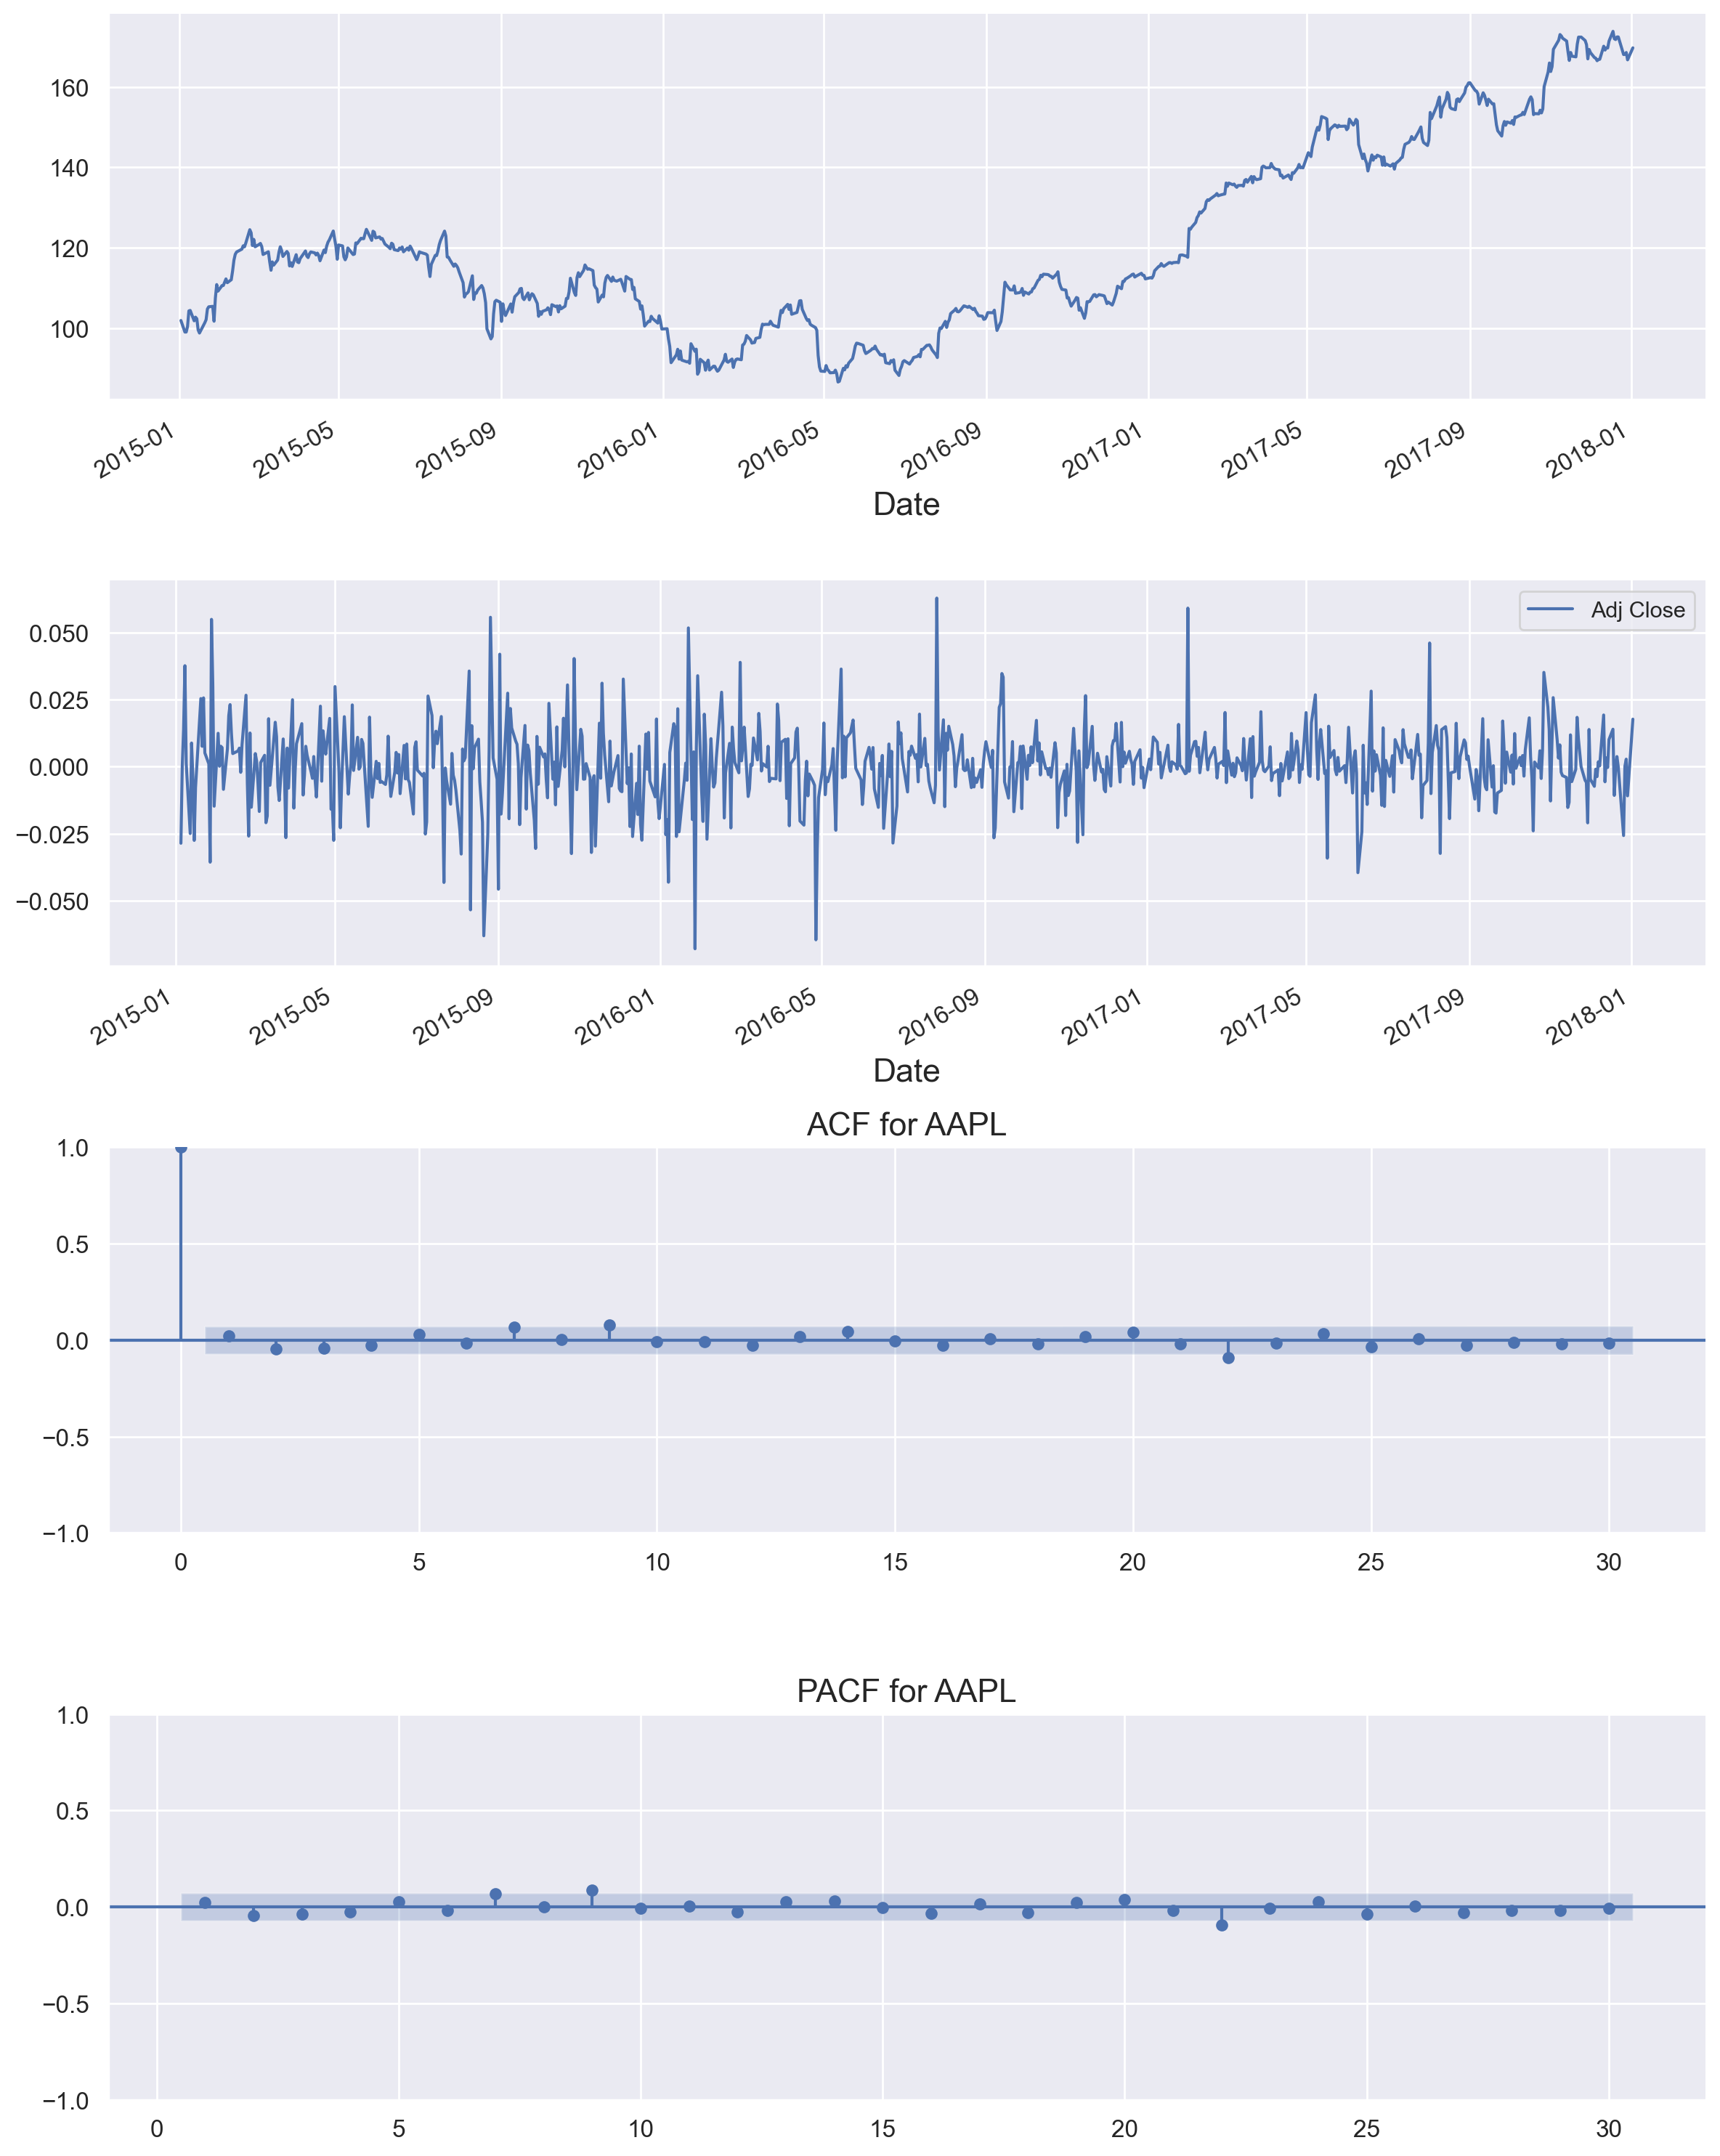

'Visual plot shows no serial correlation at relevant lags'

In [110]:
aapl = pd.read_csv("datasets/aapl_daily.csv", index_col="Date", parse_dates=["Date"])

# Consider the adjusted close column
aapl_adj = aapl["Adj Close"]
aapl_returns = pd.DataFrame(np.log(aapl_adj).diff().dropna())
# plot the adjusted close price, returns, acf and pacf
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12,15))
_ = aapl_adj.plot(ax=ax1)
_ = aapl_returns.plot(ax=ax2)
_= plot_acf(aapl_returns, ax=ax3, lags=30, zero=True, alpha=0.05, title='ACF for AAPL')
_= plot_pacf(aapl_returns, ax=ax4, zero=False, alpha=0.05, lags=30, title='PACF for AAPL')
sns.despine()
plt.tight_layout()
plt.show()

"""Visual plot shows no serial correlation at relevant lags"""

In [75]:
# compute basic statistics for returns
stats = pd.concat({"obs": aapl_returns.apply(lambda x: x.shape[0]),
                   "mean": aapl_returns.mean(axis=0),
                   "std": aapl_returns.std(axis=0),
                   "autocorrelation": aapl_returns.apply(lambda s: s.autocorr(lag=1)),
                   "acf_bounds": aapl_returns.apply(lambda s: f"=+/-{np.round(2/np.sqrt(s.shape[0]),4)}") # confidence bounds for autocorrelation at 95% confidence level

}, axis=1)

stats

,obs,mean,std,autocorrelation,acf_bounds
Adj Close,755,0.000675,0.014417,0.021602,=+/-0.0728


In [103]:
# Test for white-noise in log return series
# 1. Mean zero-test - t-test
t_stat, p_value = ttest_1samp(aapl_returns, 0)
print(f"Mean Zero Test: t-statistic = {t_stat[0]}, p-value = {p_value[0]}") # Null hypothesis of mean zero cannot be rejected as p-value is very high

# 2. Normality test - Jarque-Bera
JB_stat, p_value, skew, kurtosis =jarque_bera(aapl_returns)
print(f"Normality Test: JB_statistic = {JB_stat[0]}, p-value = {p_value[0]}, skewness = {skew[0]}, kurtosis= {kurtosis[0]}") # Null hypothesis of normality is rejected

# 3. Autocorrelation - LJung Box
lb = acorr_ljungbox(aapl_returns, lags=1, return_df=True)
print(f"Autocorrelation at lag 1 Test: lb_statistic = {lb.iloc[0,0]}, p-value = {lb.iloc[0,1]}") # Null hypothesis of no autocorrelation at lag 1 cannot be rejected as p-value is very high





Mean Zero Test: t-statistic = 1.2861293975934631, p-value = 0.19879270262980664
Normality Test: JB_statistic = 330.24089402791947, p-value = 1.945812605035127e-72, skewness = -0.13554493587731511, kurtosis= 6.228658245324367
Autocorrelation at lag 1 Test: lb_statistic = 0.35098576993227554, p-value = 0.5535556393990081


### Question 2

In [ ]:
pivot_1 = (aapl.High + aapl.Low)/2
pivot_2 = (aapl.High + aapl.Low + aapl.Close)/3
p1_lr = np.log(pivot_1).diff().dropna()
p2_lr = np.log(pivot_2).diff().dropna()

# rerun autocorrelation test on derivered (pivot data)
print(acorr_ljungbox(p1_lr, lags=1, return_df=True))
print(acorr_ljungbox(p2_lr, lags=1, return_df=True))

# Null Hypothesis of no. autocorrelation is rejected

   lb_stat  lb_pvalue
1  12.4846    0.00041
     lb_stat  lb_pvalue
1  22.454746   0.000002


### Question 3

In [113]:
# Conduct unit-root test using Augmented Dickey-Fuller test
print(f"ADF pvalue for log returns: {adfuller(aapl_returns.squeeze())[1]}") # Null hypothesis of unit root is rejected as p-value is very low

ADF pvalue for log returns: 0.0


## Exercise 6

Volatility measures are discussed in the next chapters. I have no prior knowledge and so will be revisted.....